# 📊 Student Performance Analysis and Score Prediction

## 📌 Introduction
Education plays a vital role in shaping an individual's future. Understanding the
factors that influence student performance helps educators and institutions make
data-driven decisions to improve academic outcomes.

This project analyzes student performance using data analytics techniques. It
explores how demographic, social, and academic factors affect exam scores and
applies machine learning to predict student performance.

## 🎯 Objectives
- Perform data cleaning and preprocessing.
- Conduct exploratory data analysis (EDA).
- Visualize trends and patterns in student performance.
- Identify key factors affecting academic success.
- Build a predictive model to estimate student scores.

## 📂 Dataset
**Students Performance in Exams** dataset from Kaggle, containing information on:
- Gender
- Parental level of education
- Lunch type
- Test preparation course
- Math, Reading, and Writing scores

## 🛠️ Tools and Technologies Used
- **Python**
- **Pandas and NumPy**
- **Matplotlib and Seaborn**
- **Scikit-learn**
- **Google Colab**

In [1]:
import pandas as pd

df = pd.read_csv('/content/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [7]:
df[['math_score', 'reading_score', 'writing_score']].describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
df.groupby('gender')[['math_score', 'reading_score', 'writing_score']].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [9]:
df.groupby('test_preparation_course')[['math_score', 'reading_score', 'writing_score']].mean()

,math_score,reading_score,writing_score
test_preparation_course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


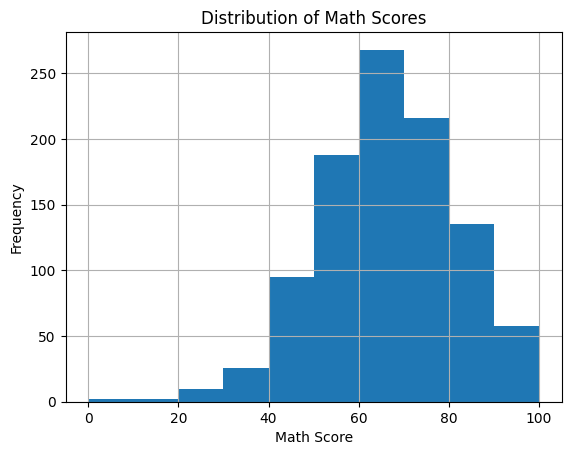

In [10]:
import matplotlib.pyplot as plt

df['math_score'].hist()
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

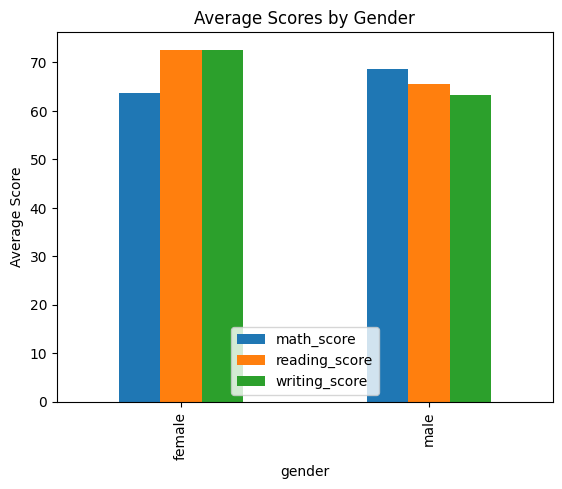

In [11]:
df.groupby('gender')[['math_score', 'reading_score', 'writing_score']].mean().plot(kind='bar')
plt.title('Average Scores by Gender')
plt.ylabel('Average Score')
plt.show()

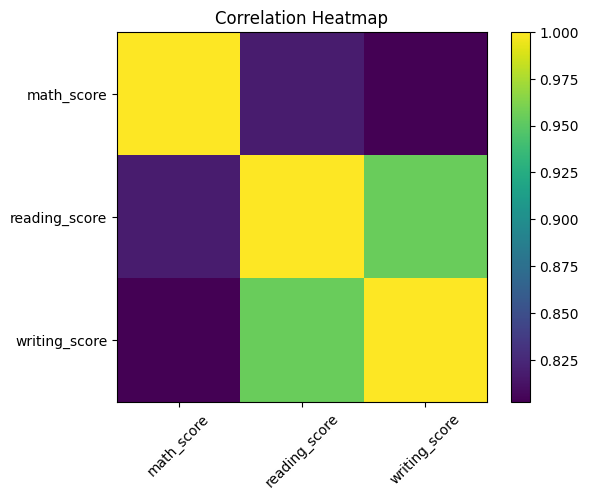

In [12]:
import matplotlib.pyplot as plt

corr = df[['math_score', 'reading_score', 'writing_score']].corr()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Correlation Heatmap')
plt.show()

In [13]:
df.groupby('parental_level_of_education')[['math_score', 'reading_score', 'writing_score']].mean()

,math_score,reading_score,writing_score
parental_level_of_education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [14]:
df.groupby('lunch')[['math_score', 'reading_score', 'writing_score']].mean()

,math_score,reading_score,writing_score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X = df.drop('math_score', axis=1)
y = df['math_score']

categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 4.665547023809524
